In [10]:
import sys, os
import numpy as np

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

sys.path.append(os.path.dirname(os.getcwd()))
from Predictor import Predictor
from PartialVAE import PartialVAE
from Flow import Flow
from train_utils import (
    set_seed,
    train_predictor,
    train_VAE,
    train_Flow,
    run_feature_acquisition,
)

# Load Dataset

In [2]:
ROOT_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(ROOT_DIR, "data", "cube")

X_train = torch.load(f"{DATA_DIR}/X_train_cdf.pt").float()
y_train = torch.load(f"{DATA_DIR}/y_train.pt").long()

X_val   = torch.load(f"{DATA_DIR}/X_val_cdf.pt").float()
y_val   = torch.load(f"{DATA_DIR}/y_val.pt").long()

X_test = torch.load(f"{DATA_DIR}/X_test_cdf.pt").float()
y_test = torch.load(f"{DATA_DIR}/y_test.pt").long()

# Train Predictor

In [ ]:
batch_size = 128
epochs = 100
lr = 0.0003
weight_decay = 1e-4
D = 20  # feature 개수 고정

predictor = Predictor(in_dim=20, hidden_dim=150, out_dim=8, num_hidden=2)
optimizer = AdamW(predictor.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()

train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)

train_predictor(
    predictor=predictor,
    train_loader=train_loader,
    X_val=X_val,
    y_val=y_val,
    D=D,
    epochs=epochs,
    optimizer=optimizer,
    criterion=criterion
)

Epoch 1/1 | train_loss=1.1291 | val_loss=0.9297 | val_acc=0.6421 | lr=0.000300
Best validation accuracy = 0.6421


# Train Partial VAE

In [ ]:
batch_size = 256
epochs = 100
lr = 1e-3
weight_decay = 1e-4

pvae = PartialVAE(
    input_type="continuous",
    num_con_features=20,
    num_cat_features=0,
    hidden_dim_con=150,
    most_categories=max(1, 0),   # 내부 차원 계산을 위해 최소 1
    c_dim=6,
    hid_enc=100,
    hid_dec=100,
    latent_dim=30,
    num_hidden_emb=2,
    num_hidden_enc=2,
    num_hidden_dec=2
)
optimizer = AdamW(pvae.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()

train_VAE(
    generator=pvae,
    train_loader=train_loader,
    X_val=X_val,
    D=D, # feature 개수
    epochs=epochs,
    optimizer=optimizer,
    obs_sigma=0.2,
    lr_factor=0.2,
    cooldown=0,
    min_lr=1e-7,
    scheduler_patience=5
)

[PVAE ep 01] train_loss=13.1728  train_KL=1.9980  train_NLL_X=11.1748 | val_loss=11.8762  val_KL=1.3221  val_NLL_X=10.5541 | lr=0.001000
Best val_loss = 11.8762


# Train Flow

In [6]:
batch_size = 256
epochs = 1
lr = 1e-3
weight_decay = 1e-4

flow = Flow(
    num_features=D,
    hidden_dim_flow=128,
    hidden_dim_prior=128,
    num_flow_layers=4,
    num_hidden=2,
)

train_Flow(
    generator=flow,
    train_loader=train_loader,
    X_val=X_val,
    D=D, # feature 개수
    epochs=epochs,
    optimizer=optimizer,
    lr_factor=0.2,
    cooldown=0,
    min_lr=1e-7,
    scheduler_patience=5
)

[Flow ep 00] train_loss=4.1964  train_NLL_xu=4.1964 | val_loss=4.1636  val_NLL_xu=4.1636 | lr=0.001000
Best val_loss = 4.1636


# Main Inference

In [9]:
predictor.eval()
N = X_test.size(0)
D = X_test.size(1)
x_np = X_test.cpu().numpy()
m_np = np.zeros((N, D), dtype=np.float32)

result = []

accs = run_feature_acquisition(
    predictor=predictor,
    generator=pvae,
    X_test=X_test,
    y_test=y_test,
    x_np=x_np,
    m_np=m_np,
    D=D,
    num_samples=10,
    alpha=1,
    gamma=0.2
)

result.append(accs)

Step 1/20 | Acc: 0.2835
Step 2/20 | Acc: 0.4419
Step 3/20 | Acc: 0.5668
Step 4/20 | Acc: 0.6625
Step 5/20 | Acc: 0.7353
Step 6/20 | Acc: 0.7918
Step 7/20 | Acc: 0.8252
Step 8/20 | Acc: 0.8495
Step 9/20 | Acc: 0.8631
Step 10/20 | Acc: 0.8773
Step 11/20 | Acc: 0.8837
Step 12/20 | Acc: 0.8892
Step 13/20 | Acc: 0.8933
Step 14/20 | Acc: 0.8970
Step 15/20 | Acc: 0.8975
Step 16/20 | Acc: 0.9025
Step 17/20 | Acc: 0.9062
Step 18/20 | Acc: 0.9105
Step 19/20 | Acc: 0.9144
Step 20/20 | Acc: 0.9219


# Result

전체 평균: 0.795655
표준편차: 0.0
acquisition 별 평균): [0.2835 0.4419 0.5668 0.6625 0.7353 0.7918 0.8252 0.8495 0.8631 0.8773
 0.8837 0.8892 0.8933 0.897  0.8975 0.9025 0.9062 0.9105 0.9144 0.9219]


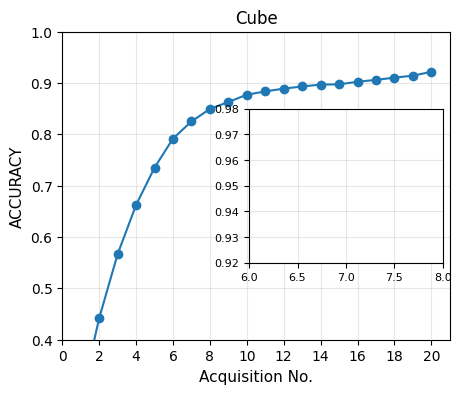

Mean ACC over all acquisitions = 0.7957


In [11]:
result = np.array(result, dtype=np.float32)

num_runs, D = result.shape
row_means = result.mean(axis=1)
overall_mean = row_means.mean()

std = row_means.std()

col_means = result.mean(axis=0)

print("전체 평균:", overall_mean)
print("표준편차:", std)
print("acquisition 별 평균):", col_means)

# 시각화
xs = np.arange(1, D + 1)

plt.figure(figsize=(5, 4))
plt.plot(xs, col_means, marker='o')
plt.xlabel('Acquisition No.', fontsize=11)
plt.ylabel('ACCURACY', fontsize=11)
plt.title('Cube', fontsize=12)
plt.xticks(np.arange(0, D+1, 2))
plt.xlim(0, D + 1)
plt.ylim(0.4, 1.0)
plt.grid(True, alpha=0.3)

# 확대 영역
ax = plt.gca()
axins = inset_axes(ax, width="50%", height="50%", loc='center right')

axins.plot(xs, col_means, marker='o')
axins.set_xlim(6, 8)
axins.set_ylim(0.92, 0.98)
axins.grid(True, alpha=0.3)
axins.tick_params(labelsize=8)

plt.show()

mean_acc = np.nanmean(col_means)
print(f"Mean ACC over all acquisitions = {mean_acc:.4f}")